In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# Set display options for better output readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [12]:
def load_data(file_path, sample_size=None):
    """
    Load data from CSV file with option to sample for faster processing
    
    Args:
        file_path: Path to the CSV file
        sample_size: Number of rows to sample (None for all rows)
    
    Returns:
        DataFrame with loaded data
    """
    print(f"Loading data from {file_path}...")
    start_time = time.time()
    
    if sample_size:
        # Read in just the first few rows to get column names
        df_sample = pd.read_csv(file_path, nrows=5)
        # Count total rows without loading entire file
        total_rows = sum(1 for _ in open(file_path)) - 1  # Subtract header
        # Calculate skip rows to get distributed sample
        skip_rows = sorted(list(range(1, total_rows + 1)))[1::int(total_rows/sample_size)]
        # Read sampled data
        df = pd.read_csv(file_path, skiprows=skip_rows)
        print(f"Sampled {len(df)} rows from {total_rows} total rows")
    else:
        # Read full file
        df = pd.read_csv(file_path)
    
    print(f"Data loaded in {time.time() - start_time:.2f} seconds")
    return df
    

In [13]:
def explore_data(df):
    """
    Perform basic exploratory data analysis
    
    Args:
        df: DataFrame to explore
    """
    # Basic info
    print("\n--- Basic Dataset Information ---")
    print(f"Dataset shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage().sum() / (1024 * 1024):.2f} MB")
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print("\n--- Missing Values ---")
    if missing_values.any():
        print(missing_values[missing_values > 0])
    else:
        print("No missing values found")
    
    # Check for Infinity values
    inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    print(f"\nNumber of infinity values: {inf_count}")
    
    # Check for column types
    print("\n--- Column Types ---")
    print(df.dtypes.value_counts())
    
    # Check for label column
    label_columns = [col for col in df.columns if 'label' in col.lower()]
    if label_columns:
        print("\n--- Attack Labels ---")
        for col in label_columns:
            print(f"\nLabel column: {col}")
            label_counts = df[col].value_counts()
            print(label_counts)
            
            # Plot label distribution
            plt.figure(figsize=(10, 6))
            ax = sns.countplot(y=col, data=df)
            plt.title('Distribution of Attack Labels')
            
            # Add count and percentage labels
            total = len(df)
            for p in ax.patches:
                count = p.get_width()
                percentage = 100 * count / total
                ax.annotate(f'{int(count)} ({percentage:.1f}%)', 
                            (p.get_width(), p.get_y() + p.get_height()/2),
                            ha='left', va='center')
            
            plt.tight_layout()
            plt.show()
    else:
        print("\nNo label column found with 'label' in its name")
        
    # Check numeric feature distributions
    print("\n--- Numeric Feature Statistics ---")
    numeric_df = df.select_dtypes(include=[np.number])
    print(numeric_df.describe().transpose()[['min', 'mean', 'max', 'std']])
    
    # Return potential label column if found
    return label_columns[0] if label_columns else None

In [14]:
def analyze_features_for_anomaly_detection(df, label_col=None):
    """
    Analyze features for anomaly detection potential
    
    Args:
        df: DataFrame to analyze
        label_col: Name of the label column if available
    """
    print("\n--- Feature Analysis for Anomaly Detection ---")
    
    # Check for highly correlated features
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Remove label column from correlation analysis if it's numeric
    if label_col and label_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[label_col])
    
    # Replace infinity values with NaN, then fill NaN with 0
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Calculate correlation matrix
    print("Calculating feature correlations...")
    corr_matrix = numeric_df.corr()
    
    # Find highly correlated feature pairs
    high_corr_features = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.9:
                high_corr_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    
    print(f"\nFound {len(high_corr_features)} highly correlated feature pairs (|r| > 0.9)")
    if high_corr_features:
        print("Top 10 highly correlated features:")
        for feat1, feat2, corr in sorted(high_corr_features, key=lambda x: abs(x[2]), reverse=True)[:10]:
            print(f"{feat1} <-> {feat2}: {corr:.4f}")
    
    # Identify features with high variance
    print("\nFeatures with highest variance (scaled):")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df)  # No need for fillna(0) since we already handled it
    scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
    var_series = scaled_df.var()
    print(var_series.sort_values(ascending=False).head(10))
    
    # If there's a label column, analyze feature importance for different attack types
    if label_col and label_col in df.columns:
        print("\n--- Feature Distributions by Attack Type ---")
        # Select features with highest variance
        top_features = var_series.sort_values(ascending=False).head(5).index.tolist()
        
        for feature in top_features:
            try:
                plt.figure(figsize=(12, 8))
                plt.title(f'Distribution of {feature} by Attack Type')
                
                # Handle outliers for better visualization
                feature_data = df.copy()
                q1 = feature_data[feature].quantile(0.01)
                q3 = feature_data[feature].quantile(0.99)
                feature_data[feature] = feature_data[feature].clip(q1, q3)
                
                # Create boxplot for each attack type
                sns.boxplot(x=label_col, y=feature, data=feature_data)
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Error plotting feature {feature}: {e}")

In [15]:
def simple_isolation_forest_test(df, label_col=None):
    """
    Test Isolation Forest algorithm on the dataset
    
    Args:
        df: DataFrame to use
        label_col: Name of the label column if available
    """
    if not label_col or label_col not in df.columns:
        print("No label column available for evaluation")
        return
    
    print("\n--- Isolation Forest Test ---")
    
    # Select features (exclude non-numeric and label columns)
    feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if label_col in feature_cols:
        feature_cols.remove(label_col)
    
    # Create a binary label for attack vs normal
    df['is_attack'] = ~df[label_col].str.contains('BENIGN', case=False, na=False)
    
    # Handle missing and infinite values
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Train isolation forest model
    print("Training Isolation Forest model...")
    model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
    
    # Get anomaly predictions (-1 for anomalies, 1 for normal)
    preds = model.fit_predict(X)
    
    # Convert to binary (1 for anomalies, 0 for normal)
    anomalies = np.where(preds == -1, 1, 0)
    
    # Compare with actual labels
    print("\nIsolation Forest Results:")
    print(confusion_matrix(df['is_attack'], anomalies))
    print("\nClassification Report:")
    print(classification_report(df['is_attack'], anomalies))


===== Exploring Thursday Dataset (SQL Injection, Web Attacks) =====
Loading data from C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv...
Sampled 943717 rows from 1048575 total rows
Data loaded in 6.63 seconds

--- Basic Dataset Information ---
Dataset shape: (943717, 80)
Memory usage: 576.00 MB

--- Missing Values ---
Flow Byts/s    3247
dtype: int64

Number of infinity values: 6917

--- Column Types ---
int64      54
float64    24
object      2
Name: count, dtype: int64

--- Attack Labels ---

Label column: Label
Label
Benign              943389
Brute Force -Web       226
Brute Force -XSS        71
SQL Injection           31
Name: count, dtype: int64


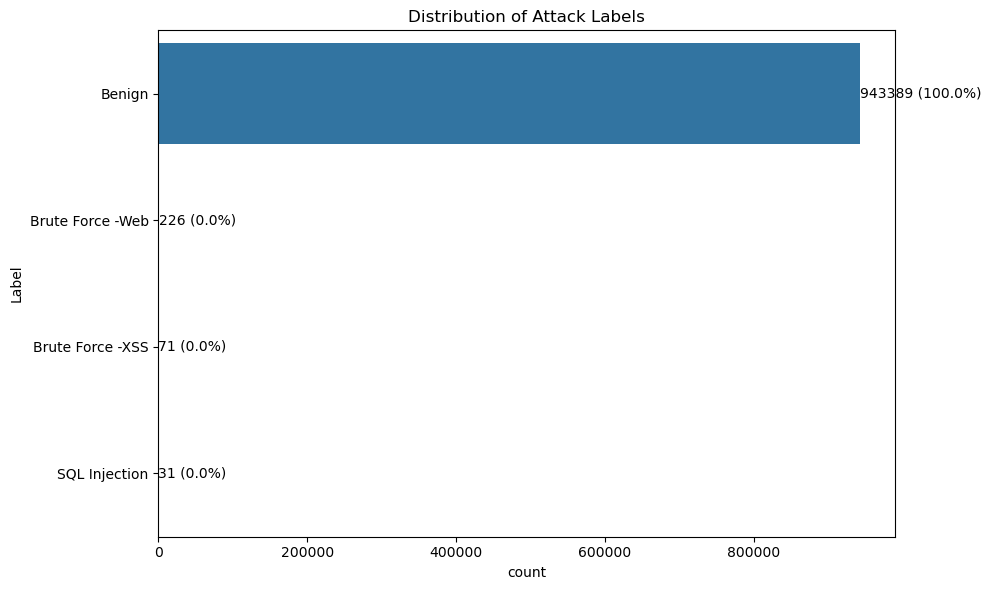


--- Numeric Feature Statistics ---
                        min          mean           max           std
Dst Port       0.000000e+00  8.964236e+03  6.553300e+04  1.810051e+04
Protocol       0.000000e+00  9.114998e+00  1.700000e+01  5.112362e+00
Flow Duration -8.282200e+11  1.454750e+07  1.200000e+08  1.555240e+09
Tot Fwd Pkts   1.000000e+00  6.330840e+00  1.147800e+04  6.973988e+01
Tot Bwd Pkts   0.000000e+00  8.220560e+00  3.841800e+04  2.049190e+02
...                     ...           ...           ...           ...
Active Min     0.000000e+00  4.498220e+04  1.084622e+08  5.896212e+05
Idle Mean      0.000000e+00  1.196621e+07  3.955714e+11  9.290952e+08
Idle Std       0.000000e+00  1.746642e+06  2.622479e+11  5.746228e+08
Idle Max       0.000000e+00  1.509611e+07  9.684340e+11  2.036918e+09
Idle Min       0.000000e+00  9.565089e+06  2.399340e+11  2.564058e+08

[78 rows x 4 columns]


In [16]:
# Update this path to your actual file location
thursday_file = "C:\\Users\\mcgahanc\\Desktop\\msc Cybersecurity\\Semester 3\\AIML in CyberSec\\CA\\Datasets\\Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv"

print("\n===== Exploring Thursday Dataset (SQL Injection, Web Attacks) =====")
df_thursday = load_data(thursday_file, sample_size=100000)  # Sample 100k rows for quicker analysis
thursday_label_col = explore_data(df_thursday)

In [17]:
# Check for infinity values in the Thursday dataset
inf_values = df_thursday.select_dtypes(include=[np.number]).isin([np.inf, -np.inf]).sum().sum()
print(f"Number of infinity values in Thursday dataset: {inf_values}")

# Check which columns have infinity values
inf_cols = df_thursday.select_dtypes(include=[np.number]).columns[df_thursday.select_dtypes(include=[np.number]).isin([np.inf, -np.inf]).any()].tolist()
print(f"Columns with infinity values: {inf_cols}")

Number of infinity values in Thursday dataset: 6917
Columns with infinity values: ['Flow Byts/s', 'Flow Pkts/s']



--- Feature Analysis for Anomaly Detection ---
Calculating feature correlations...

Found 67 highly correlated feature pairs (|r| > 0.9)
Top 10 highly correlated features:
Tot Fwd Pkts <-> Subflow Fwd Pkts: 1.0000
Tot Bwd Pkts <-> Subflow Bwd Pkts: 1.0000
TotLen Fwd Pkts <-> Subflow Fwd Byts: 1.0000
TotLen Bwd Pkts <-> Subflow Bwd Byts: 1.0000
Fwd Pkt Len Mean <-> Fwd Seg Size Avg: 1.0000
Fwd PSH Flags <-> SYN Flag Cnt: 1.0000
Bwd Pkt Len Mean <-> Bwd Seg Size Avg: 1.0000
Flow IAT Min <-> Fwd IAT Min: 1.0000
Flow IAT Max <-> Fwd IAT Max: 1.0000
Flow IAT Std <-> Fwd IAT Std: 1.0000

Features with highest variance (scaled):
Flow IAT Max         1.000001
Fwd IAT Max          1.000001
Tot Fwd Pkts         1.000001
Subflow Fwd Pkts     1.000001
SYN Flag Cnt         1.000001
Fwd PSH Flags        1.000001
Fwd Act Data Pkts    1.000001
Subflow Bwd Byts     1.000001
TotLen Bwd Pkts      1.000001
Bwd IAT Tot          1.000001
dtype: float64

--- Feature Distributions by Attack Type ---


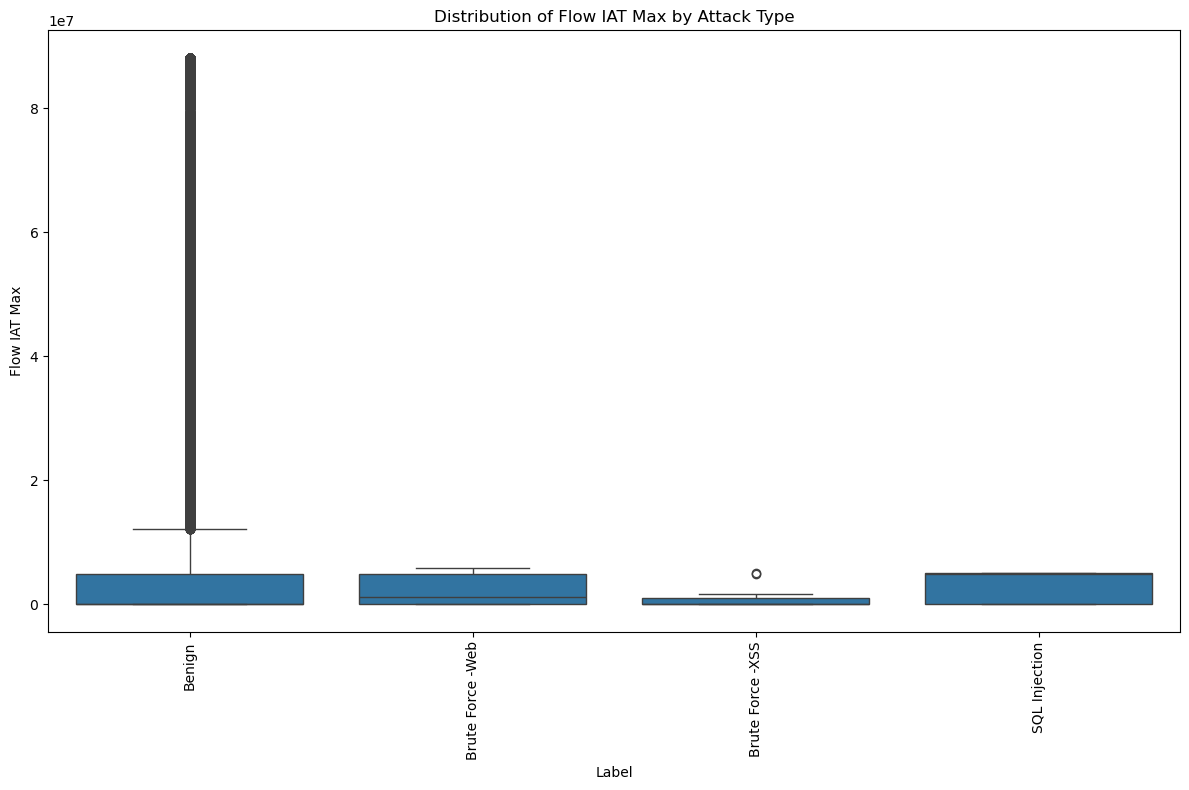

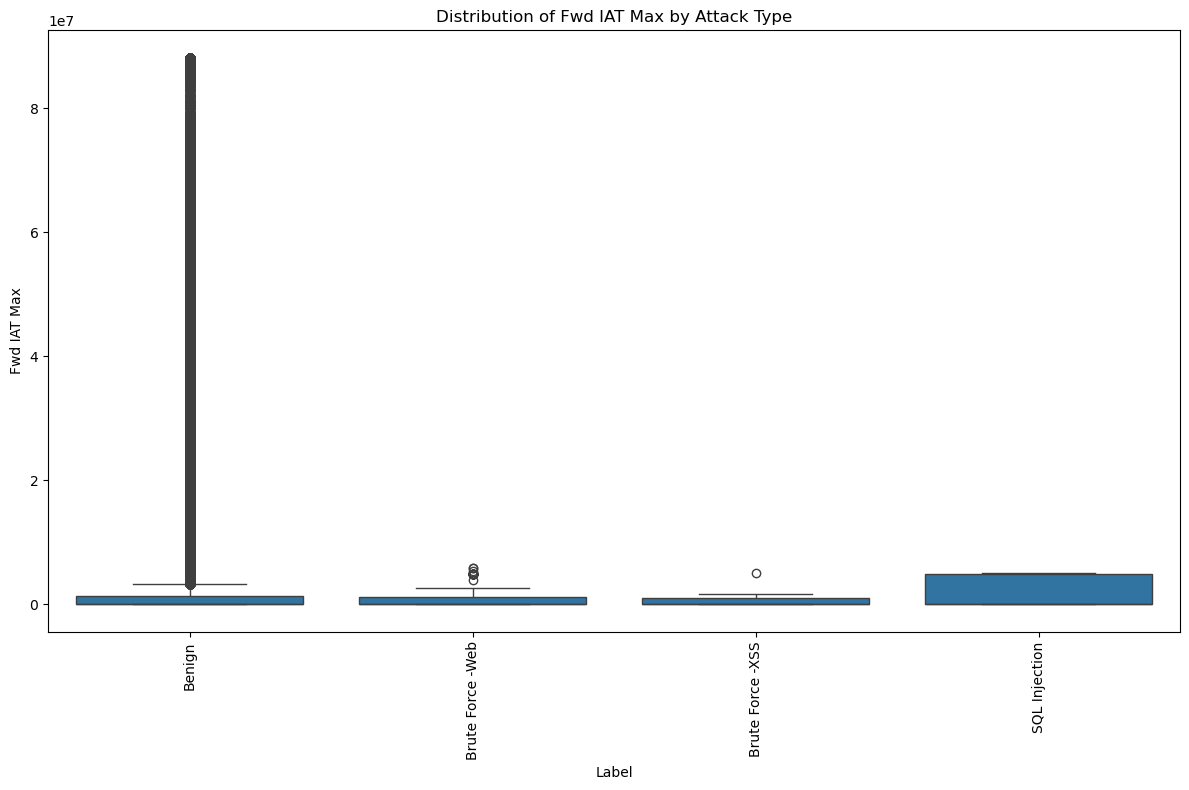

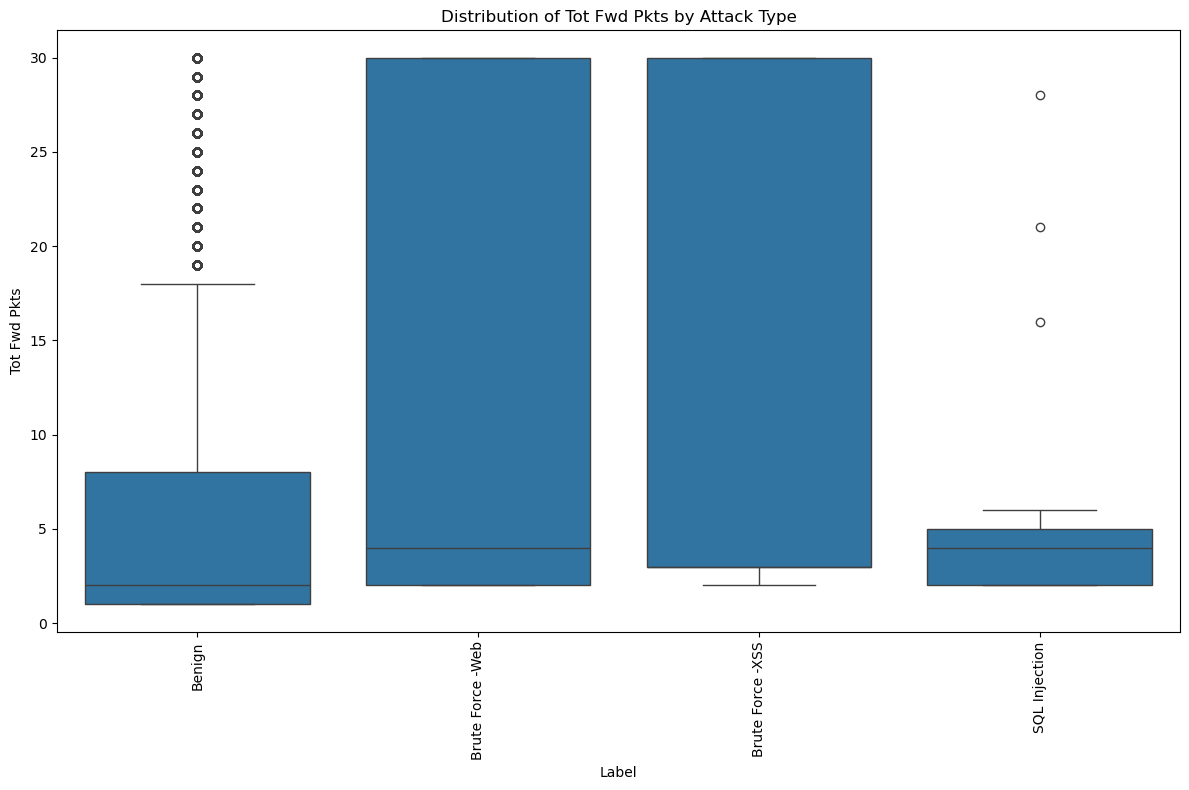

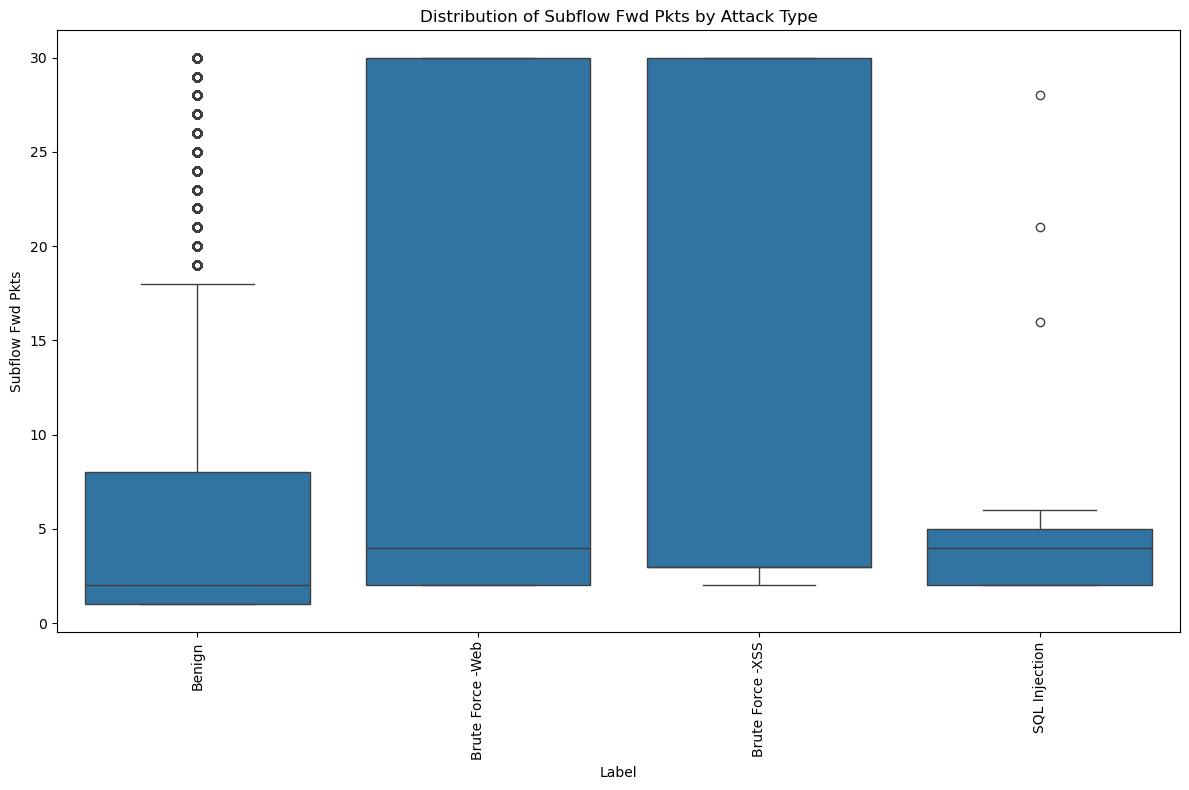

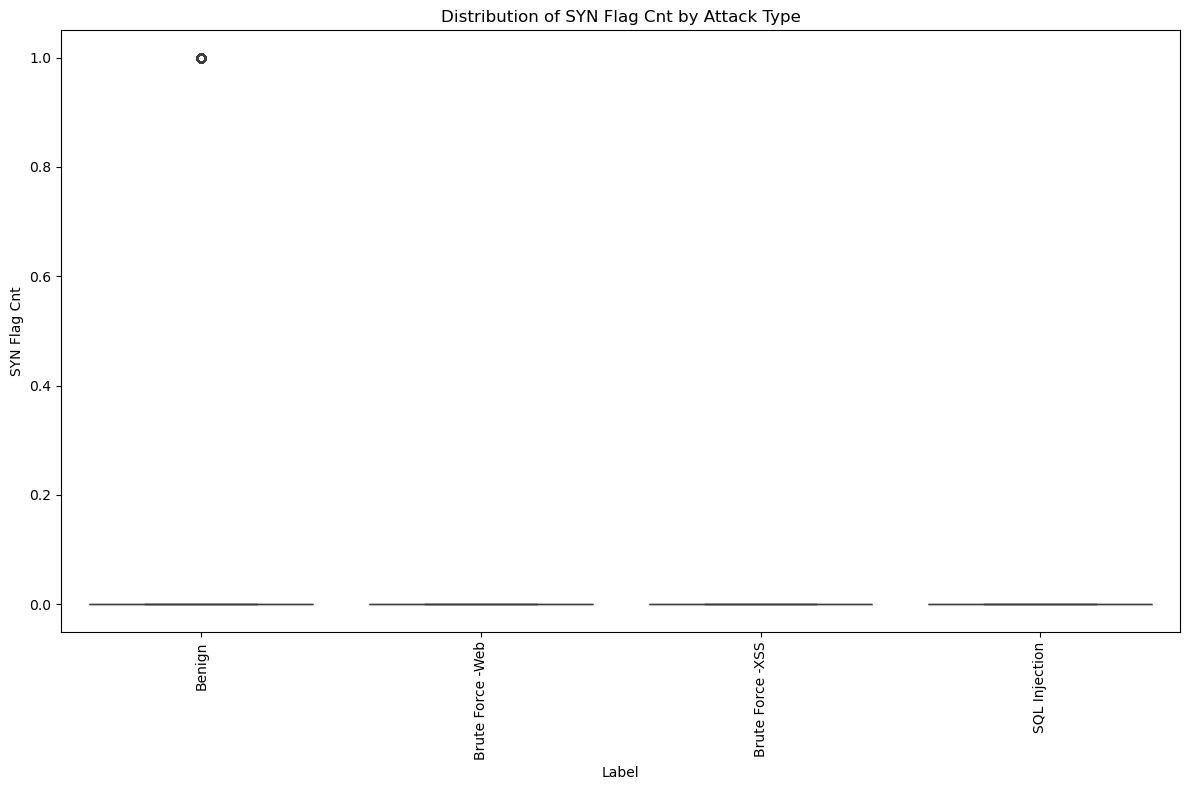


--- Isolation Forest Test ---
Training Isolation Forest model...


C:\Users\mcgahanc\AppData\Local\miniconda3\envs\api_security_ml\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(



Isolation Forest Results:
[[849134  94255]
 [   225    103]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95    943389
        True       0.00      0.31      0.00       328

    accuracy                           0.90    943717
   macro avg       0.50      0.61      0.47    943717
weighted avg       1.00      0.90      0.95    943717



In [18]:
analyze_features_for_anomaly_detection(df_thursday, thursday_label_col)
simple_isolation_forest_test(df_thursday, thursday_label_col)


===== Exploring Friday Dataset (SQL Injection, Web Attacks) =====
Loading data from C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Friday-23-02-2018_TrafficForML_CICFlowMeter.csv...
Sampled 943717 rows from 1048575 total rows
Data loaded in 6.76 seconds

--- Basic Dataset Information ---
Dataset shape: (943717, 80)
Memory usage: 576.00 MB

--- Missing Values ---
Flow Byts/s    3389
dtype: int64

Number of infinity values: 6853

--- Column Types ---
int64      54
float64    24
object      2
Name: count, dtype: int64

--- Attack Labels ---

Label column: Label
Label
Benign              943208
Brute Force -Web       326
Brute Force -XSS       135
SQL Injection           48
Name: count, dtype: int64


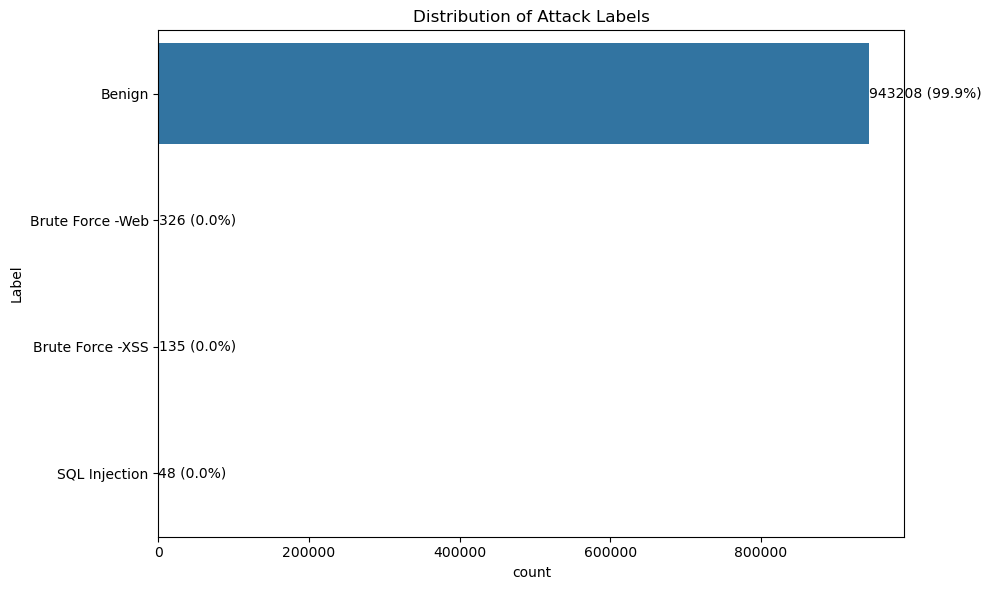


--- Numeric Feature Statistics ---
               min          mean           max           std
Dst Port       0.0  9.349024e+03  6.553400e+04  1.843743e+04
Protocol       0.0  8.973805e+00  1.700000e+01  5.043112e+00
Flow Duration  0.0  1.873133e+07  1.200000e+08  3.633807e+07
Tot Fwd Pkts   1.0  6.971337e+00  5.809100e+04  1.233993e+02
Tot Bwd Pkts   0.0  1.002012e+01  1.231180e+05  3.209935e+02
...            ...           ...           ...           ...
Active Min     0.0  5.022235e+04  1.131706e+08  7.303814e+05
Idle Mean      0.0  9.655802e+06  1.199916e+08  2.500161e+07
Idle Std       0.0  1.370238e+05  7.157844e+07  1.597445e+06
Idle Max       0.0  9.772778e+06  1.199916e+08  2.512574e+07
Idle Min       0.0  9.517580e+06  1.199916e+08  2.495618e+07

[78 rows x 4 columns]


In [19]:
# Update this path to your actual file location
friday_file = "C:\\Users\\mcgahanc\\Desktop\\msc Cybersecurity\\Semester 3\\AIML in CyberSec\\CA\\Datasets\\Friday-23-02-2018_TrafficForML_CICFlowMeter.csv"

print("\n===== Exploring Friday Dataset (SQL Injection, Web Attacks) =====")
df_friday = load_data(friday_file, sample_size=100000)  # Sample 100k rows for quicker analysis
friday_label_col = explore_data(df_friday)


--- Feature Analysis for Anomaly Detection ---
Calculating feature correlations...

Found 62 highly correlated feature pairs (|r| > 0.9)
Top 10 highly correlated features:
Bwd Pkt Len Mean <-> Bwd Seg Size Avg: 1.0000
Tot Fwd Pkts <-> Subflow Fwd Pkts: 1.0000
Tot Bwd Pkts <-> Subflow Bwd Pkts: 1.0000
TotLen Fwd Pkts <-> Subflow Fwd Byts: 1.0000
TotLen Bwd Pkts <-> Subflow Bwd Byts: 1.0000
Fwd Pkt Len Mean <-> Fwd Seg Size Avg: 1.0000
Fwd PSH Flags <-> SYN Flag Cnt: 1.0000
RST Flag Cnt <-> ECE Flag Cnt: 1.0000
Tot Bwd Pkts <-> Bwd Header Len: 1.0000
Bwd Header Len <-> Subflow Bwd Pkts: 1.0000

Features with highest variance (scaled):
Pkt Len Std         1.000001
Fwd Pkt Len Mean    1.000001
Idle Std            1.000001
Fwd Seg Size Avg    1.000001
Fwd IAT Tot         1.000001
Fwd Pkt Len Min     1.000001
Down/Up Ratio       1.000001
Bwd Pkt Len Max     1.000001
Bwd Pkts/s          1.000001
Fwd Header Len      1.000001
dtype: float64

--- Feature Distributions by Attack Type ---


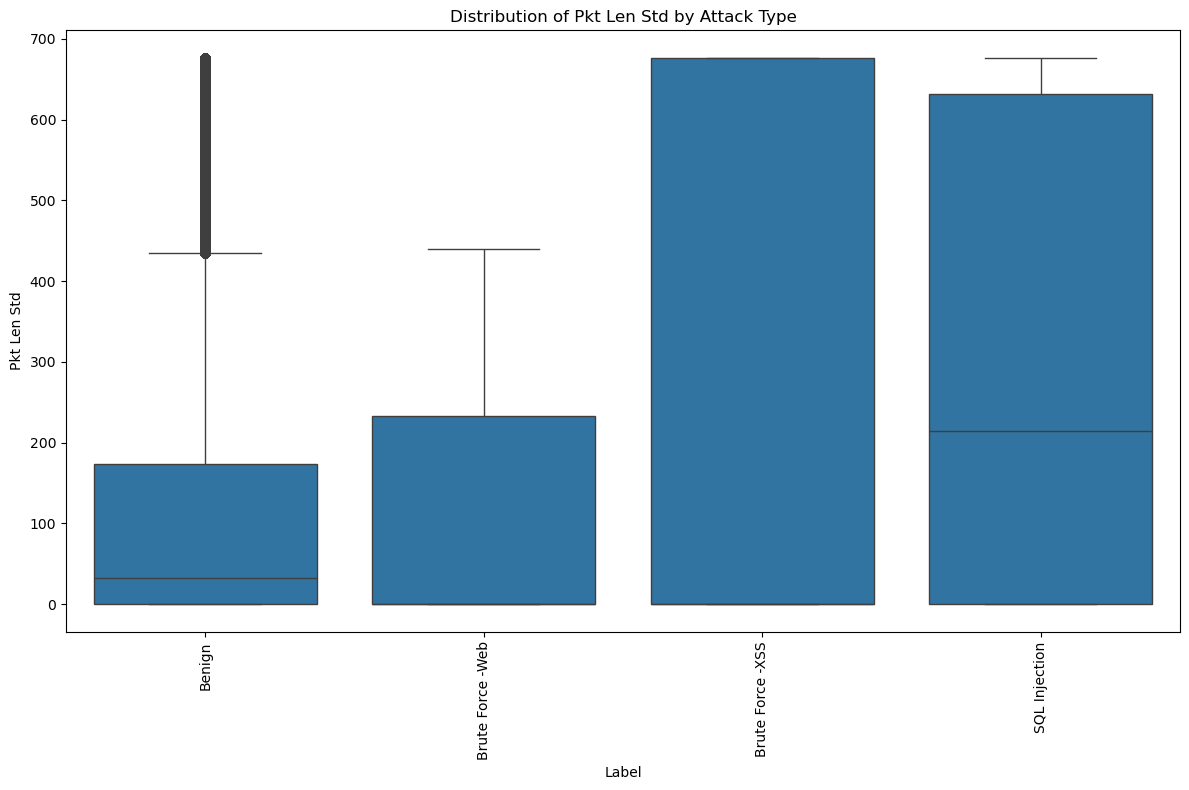

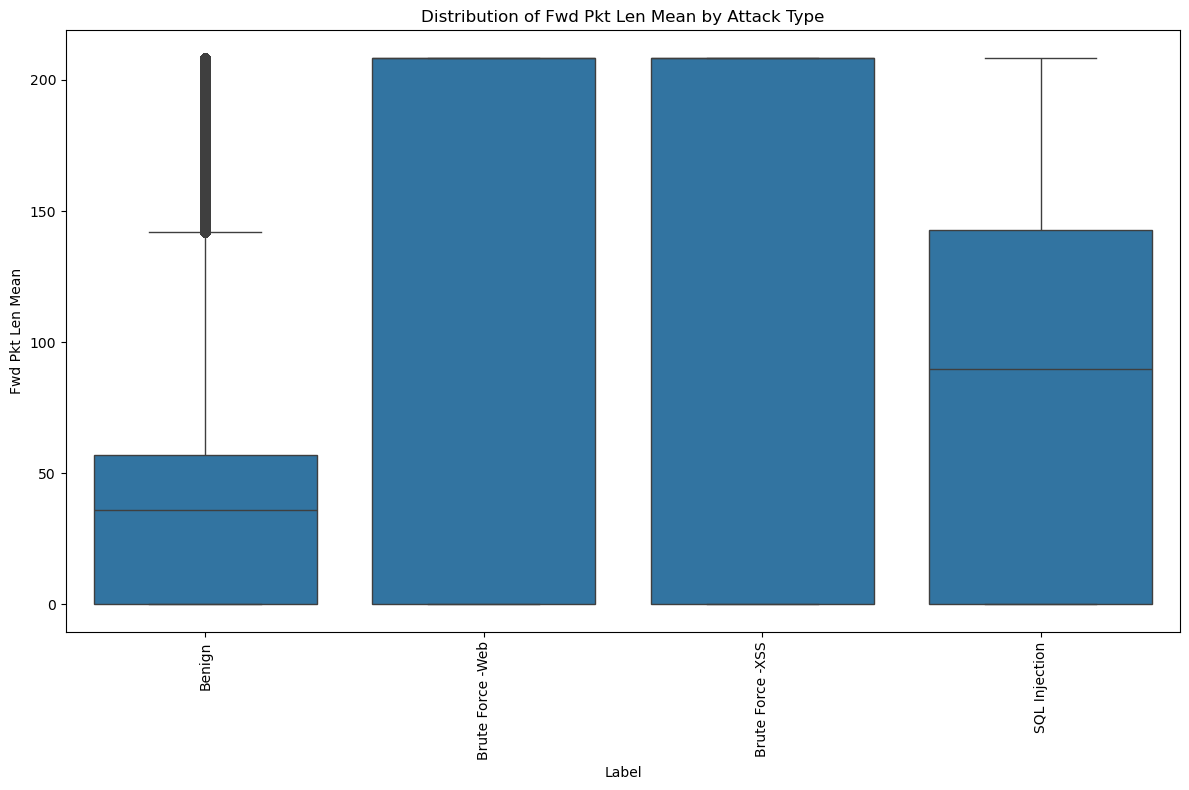

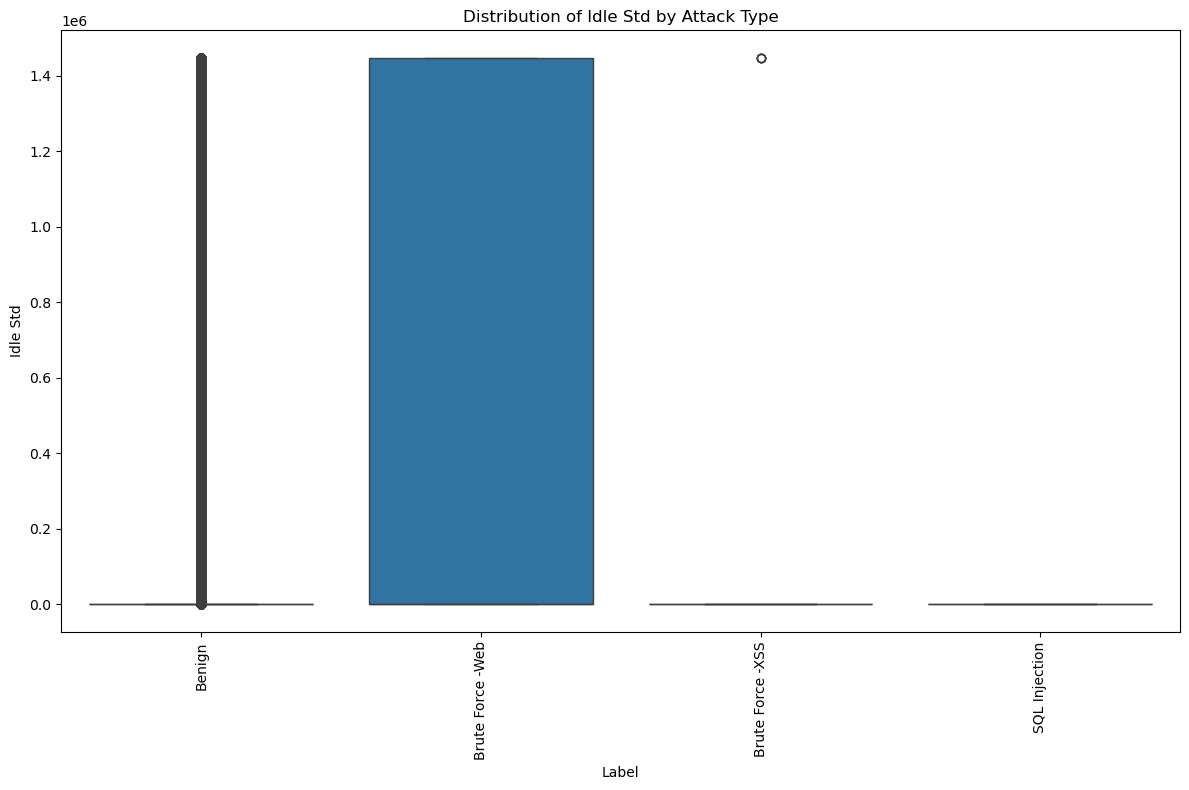

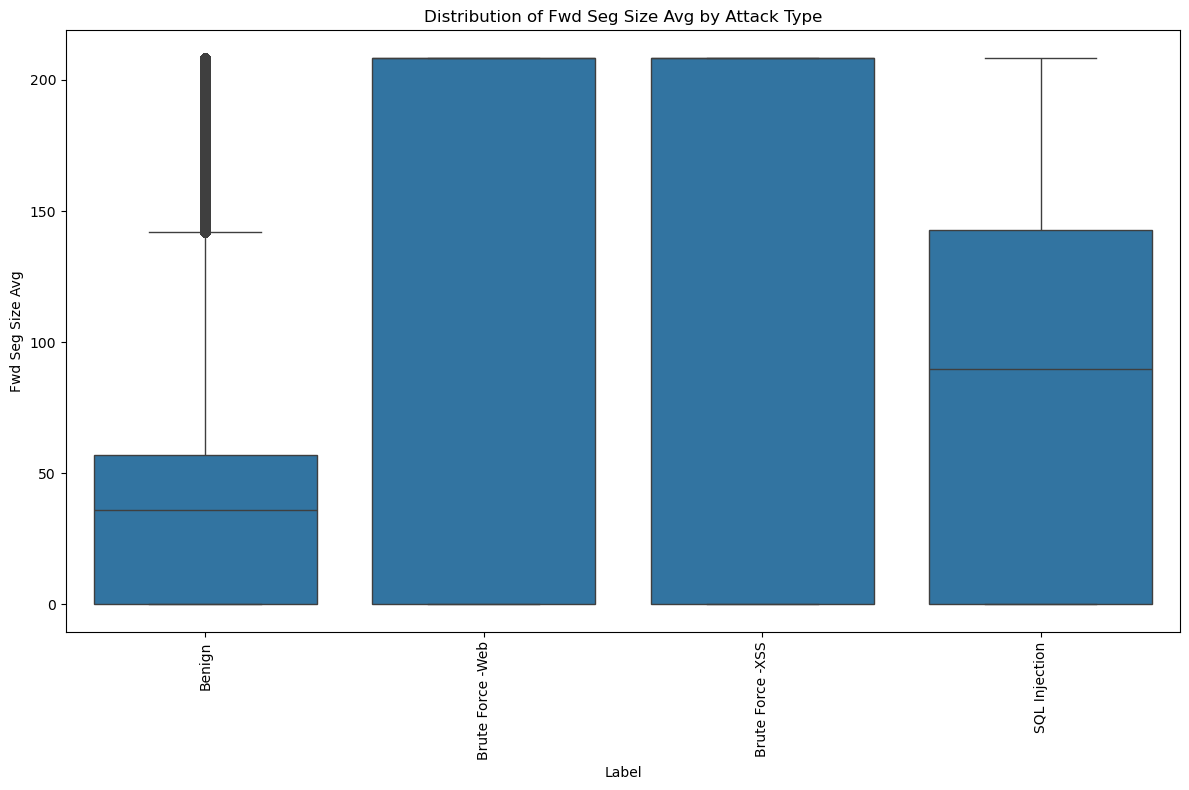

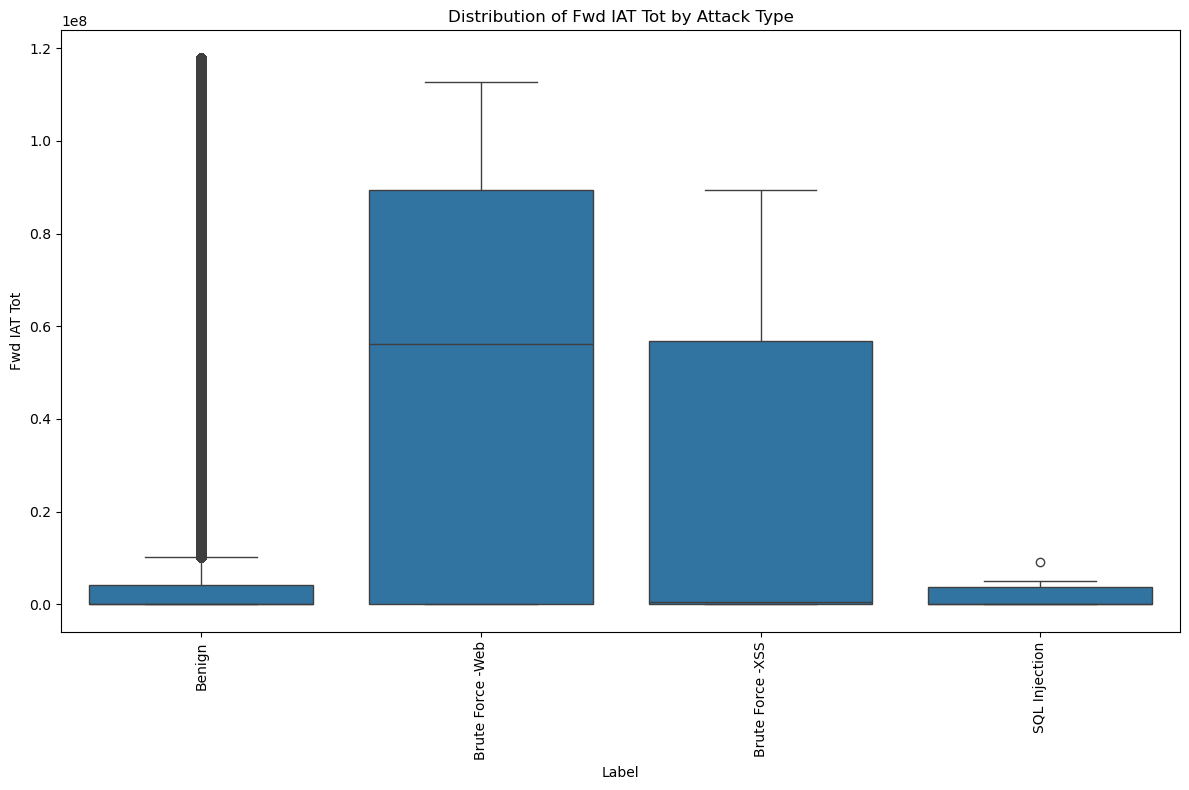


--- Isolation Forest Test ---
Training Isolation Forest model...


C:\Users\mcgahanc\AppData\Local\miniconda3\envs\api_security_ml\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(



Isolation Forest Results:
[[849112  94096]
 [   233    276]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95    943208
        True       0.00      0.54      0.01       509

    accuracy                           0.90    943717
   macro avg       0.50      0.72      0.48    943717
weighted avg       1.00      0.90      0.95    943717



In [20]:
analyze_features_for_anomaly_detection(df_friday, friday_label_col)
simple_isolation_forest_test(df_friday, friday_label_col)